# Imports & API Client Init

In [7]:
import json
import logging
import pandas as pd
from polymarket_client import PolymarketClient
from feature_engineer import engineer_features
from hmm import train_regime_model

logging.basicConfig(level=logging.WARNING)
client = PolymarketClient()

# Feature Engineering

In [8]:
market_id = "1163699"
market = client.get_market_details(market_id)
token_ids = json.loads(market.get("clobTokenIds", "[]"))
target_token_id = token_ids[0]

raw_response = client.get_token_history(
    token_id=target_token_id, fidelity=60, total_days=90, chunk_days=7
)
df = engineer_features(raw_response["history"])
print(f"Rows: {len(df)}")
df.head()

Rows: 2101


,price,log_return,volatility_24h
timestamp,,,
2026-05-06 14:00:11,0.665,0.007547,0.016895
2026-05-06 15:00:12,0.655,-0.015152,0.017212
2026-05-06 16:00:07,0.655,0.000000,0.016880
2026-05-06 17:00:13,0.650,-0.007663,0.016674
2026-05-06 18:00:09,0.650,0.000000,0.016674


# Model Training

In [9]:
n_components = 3
model, states = train_regime_model(df, n_components=n_components)
df["state"] = states
print(
    f"Model log-likelihood: {model.score(df[['log_return','volatility_24h']].values):.4f}"
)

Model log-likelihood: -4349.0883


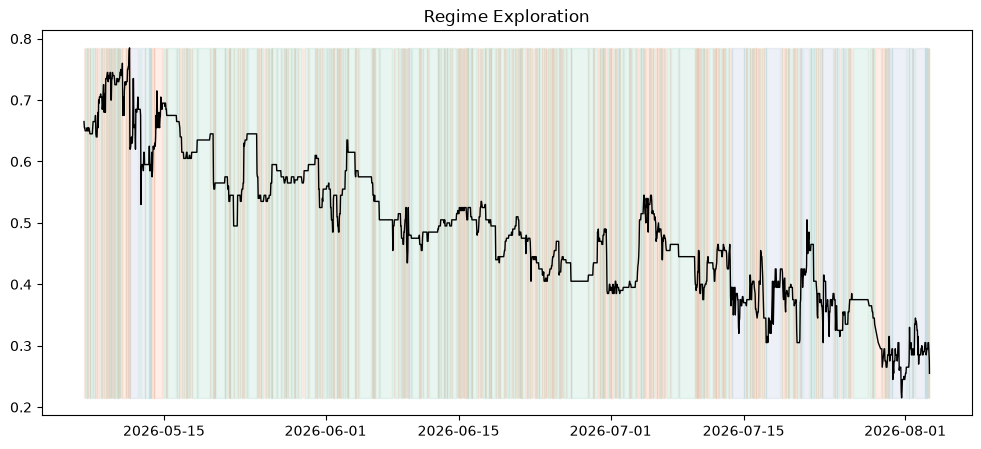

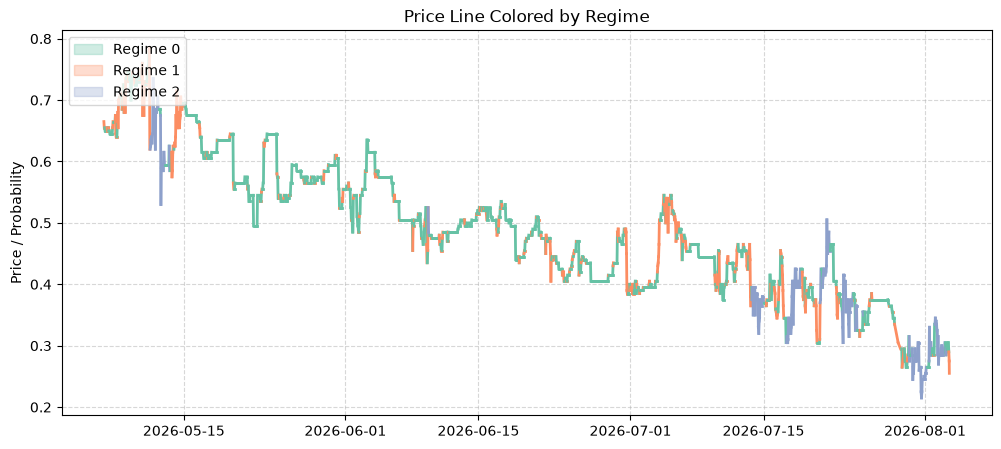

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

colors = ["#66c2a5", "#fc8d62", "#8da0cb"]

fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df.index, df["price"], color="black", lw=1)
for i in range(n_components):
    mask = df["state"] == i
    ax1.fill_between(
        df.index,
        df["price"].min(),
        df["price"].max(),
        where=mask,
        color=colors[i],
        alpha=0.15,
        step="post",
    )
ax1.set_title("Regime Exploration")
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 5))
for i in range(len(df) - 1):
        s = df["state"].iloc[i]
        ax2.plot(
            df.index[i : i + 2],
            df["price"].iloc[i : i + 2],
            color=colors[s],
            lw=2,
        )
ax2.set_ylabel("Price / Probability")
ax2.set_title("Price Line Colored by Regime")
ax2.grid(True, linestyle="--", alpha=0.5)

legend_handles = [
        Patch(color=colors[i], alpha=0.3, label=f"Regime {i}")
        for i in range(n_components)
    ]

ax2.legend(handles=legend_handles, loc="upper left")
plt.show()

In [16]:
df.groupby("state").agg(
    count=("price", "size"),
    pct_of_time=("price", lambda x: len(x) / len(df) * 100),
    avg_price=("price", "mean"),
    avg_return=("log_return", "mean"),
    avg_volatility=("volatility_24h", "mean"),
    std_return=("log_return", "std"),
).round(4)

,count,pct_of_time,avg_price,avg_return,avg_volatility,std_return
state,,,,,,
0,1324,63.0176,0.5024,0.0000,0.0176,0.0000
1,536,25.5117,0.5057,-0.0021,0.0229,0.0393
2,241,11.4707,0.3874,0.0008,0.0595,0.0654


In [19]:
pd.DataFrame(
    model.transmat_,
    index=[f"From {i}" for i in range(n_components)],
    columns=[f"To {i}" for i in range(n_components)],
).round(5)

,To 0,To 1,To 2
From 0,0.76488,0.22428,0.01085
From 1,0.54475,0.44843,0.00682
From 2,0.07498,0.00000,0.92502


In [20]:
state_changes = df["state"] != df["state"].shift(1)
regime_lengths = state_changes.cumsum().value_counts().sort_index()

print(f"Average regime duration: {regime_lengths.mean():.1f} hours")
print(f"Longest regime stretch: {regime_lengths.max()} hours")
print(f"Shortest regime stretch: {regime_lengths.min()} hours")

Average regime duration: 3.4 hours
Longest regime stretch: 43 hours
Shortest regime stretch: 1 hours
